In [1]:
import spacy
import pandas as pd
import spacy.lang.yo as yo
from spacy.lang.yo.stop_words import STOP_WORDS as yor_sw
from spacy.lang.en.stop_words import STOP_WORDS as en_sw
import numpy as np
import string
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from gensim.models import Word2Vec
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.utils import to_categorical
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset, Dataset
import evaluate

c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
nlp = spacy.blank('yo')

In [3]:
yor_df = pd.read_csv('combined_yordf.csv')
yor_df.head()

,tweet,label
0,Bae you try gan.,positive
1,Mo gbádùn rẹ.,positive
2,O ṣeun gan ni o.,positive
3,Ẹ ṣe o.,positive
4,Ìfẹ́ rẹ̀ dá mi lórí.,positive


In [4]:
yor_df.shape

(40127, 2)

In [5]:
yor_df.label.value_counts(normalize=True)

label
positive    0.366337
neutral     0.344506
negative    0.289157
Name: proportion, dtype: float64

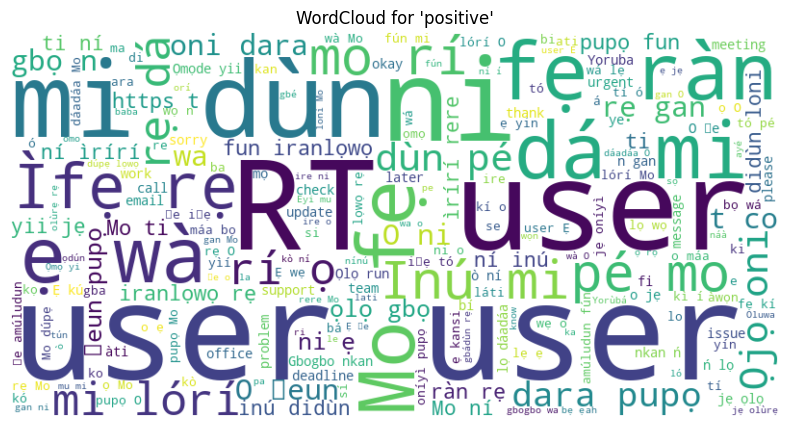

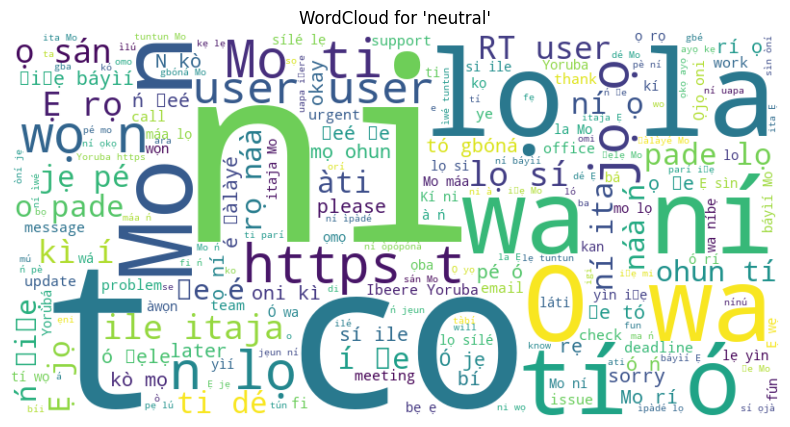

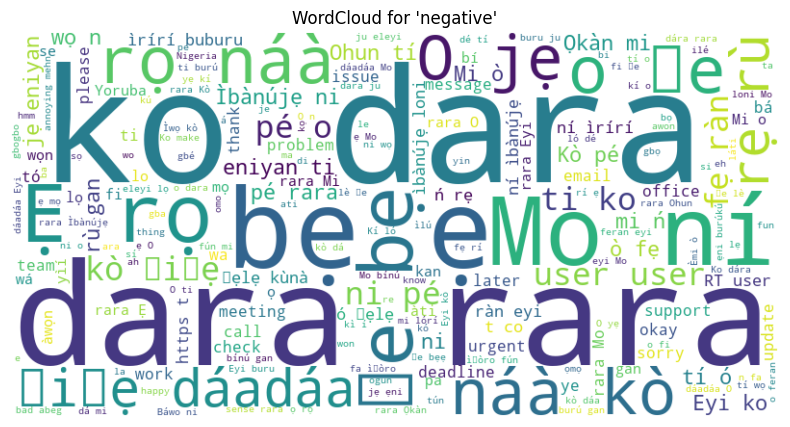

In [6]:
for label in yor_df["label"].unique():
    text = " ".join(yor_df[yor_df["label"] == label]["tweet"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"WordCloud for '{label}'")
    plt.axis("off")
    plt.show()

In [7]:
# yorsw = pd.read_csv('yor.csv')
# def preprocess_text(text):
#     if not isinstance(text, str) or not text.strip():
#         return ""
    
#     text = re.sub(r'http\S+|@\w+|#\w+|\bRT\b|"{2,}', '', text, flags=re.IGNORECASE)
#     text = re.sub(r'[.]{2,}', ' ', text)
#     text = re.sub(r'[\!\?\:\.\,]+', ' ', text)
#     text = re.sub(r'\s+', ' ', text).strip()

#     doc = nlp(text)
#     tokens = [
#         token.text.lower() for token in doc 
#         if token.text.lower() not in yorsw.word
#         and token.text not in en_sw
#         and token.text not in string.punctuation
#         and len(token.text.strip()) > 1
#         and not token.text.isdigit()
#     ]

#     return " ".join(tokens).strip() or "empty"

In [8]:
# yor_df['clean_text'] = yor_df.tweet.apply(preprocess_text)

In [9]:
# for label in yor_df["label"].unique():
#     text = " ".join(yor_df[yor_df["label"] == label]["clean_text"])
#     wc = WordCloud(width=800, height=400, background_color="white").generate(text)

#     plt.figure(figsize=(10, 5))
#     plt.imshow(wc, interpolation='bilinear')
#     plt.title(f"WordCloud for '{label}'")
#     plt.axis("off")
#     plt.show()

In [10]:
yor_df.label.value_counts()

label
positive    14700
neutral     13824
negative    11603
Name: count, dtype: int64

<Axes: ylabel='count'>

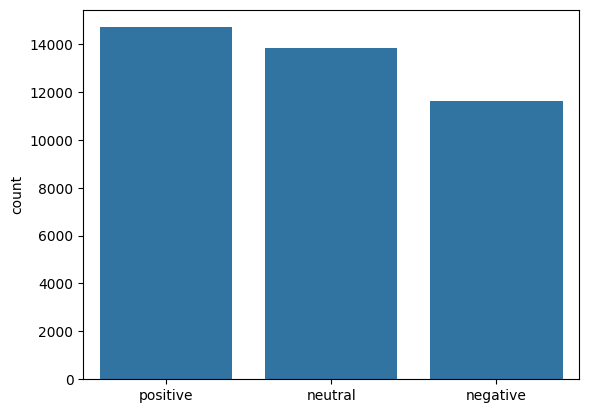

In [11]:
seaborn.countplot(x=yor_df.label.values)

In [12]:
labels = {'negative' : 0, 'neutral' : 1, 'positive' : 2}

yor_df['label'] = yor_df.label.map(labels)
yor_df.head()

,tweet,label
0,Bae you try gan.,2
1,Mo gbádùn rẹ.,2
2,O ṣeun gan ni o.,2
3,Ẹ ṣe o.,2
4,Ìfẹ́ rẹ̀ dá mi lórí.,2


In [13]:
count_positive,count_neutral,count_negative = yor_df.label.value_counts()

In [14]:
df_class_negative = yor_df[yor_df['label']== 0] 
df_class_positive = yor_df[yor_df['label']== 2]
df_class_neutral = yor_df[yor_df['label']== 1]

In [15]:
# df_class_worry_over = df_class_negative.sample(count_neutral, replace=True)
df_class_neutral_over = df_class_neutral.sample(count_positive, replace=True)
df_class_negative_over = df_class_negative.sample(count_positive, replace=True)

oversampled_data = pd.concat([df_class_neutral_over, df_class_negative_over, df_class_positive])
print(oversampled_data.label.value_counts())

label
1    14700
0    14700
2    14700
Name: count, dtype: int64


In [16]:
oversampled_data.head()

,tweet,label
37968,issue ti dé.,1
25102,Mo ní ìpàdé lọ́la.,1
7378,Ise ti awon ara ilu ran mi ti bere ni perewu -...,1
39451,call work lọ sí ile check later náà thank you ...,1
38170,Ẹ̀rọ náà ń okay báyìí. Mo ti dé. no rí ọ ní ọ̀...,1


- Word2vec

In [17]:
# def tokenize(text):
#     return str(text).lower().split()

# sentences = [tokenize(t) for t in oversampled_data['clean_text'].astype(str).tolist()]

# w2v_size = 100
# w2v_model = Word2Vec(
#     sentences,
#     vector_size=w2v_size,
#     window=5,
#     min_count=1,  
#     workers=4,
#     sg=1 
# )

# w2v_model.save("yoruba_word2vec.model")

In [18]:

# def sentence_vector(sentence, model, size):
#     tokens = tokenize(sentence)
#     vecs = []
#     for t in tokens:
#         if t in model.wv:
#             vecs.append(model.wv[t])
#     if len(vecs) == 0:
#         return np.zeros(size, dtype=np.float32)
#     return np.mean(vecs, axis=0)

In [19]:
# x = np.vstack([sentence_vector(t, w2v_model, w2v_size) for t in oversampled_data['clean_text'].astype(str).tolist()])
# y = oversampled_data['new_label'].astype(int).values

In [20]:
# print("X shape:", x.shape, "y shape:", y.shape)

In [21]:
# x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, stratify=y)

In [22]:
# train_df, test_df = train_test_split(oversampled_data, test_size=0.2, random_state=42, stratify=oversampled_data["label"])

In [23]:
# # Convert to Hugging Face Dataset
# train_dataset = Dataset.from_pandas(train_df)
# test_dataset = Dataset.from_pandas(test_df)

In [24]:
# train_dataset

In [25]:
# # AfriSenti tokenizer (handles Yoruba diacritics/code-switching better than your custom one)
# tokenizer = AutoTokenizer.from_pretrained("Davlan/afrisenti-twitter-sentiment-afroxlmr-large")

# def preprocess_function(examples):
#     return tokenizer(examples["tweet"], truncation=True, padding="max_length", max_length=128)  # Adjust max_length if needed

# tokenized_train = train_dataset.map(preprocess_function, batched=True)
# tokenized_test = test_dataset.map(preprocess_function, batched=True)

In [26]:
# # Load AfriSenti model
# model = AutoModelForSequenceClassification.from_pretrained(
#     "Davlan/afrisenti-twitter-sentiment-afroxlmr-large", num_labels=3
# )

In [27]:
# # Metrics (weighted F1, like your classification_report)
# f1_metric = evaluate.load("f1")
# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     predictions = np.argmax(logits, axis=-1)
#     return f1_metric.compute(predictions=predictions, references=labels, average="weighted")

In [28]:
# # Training args (tune as needed)
# training_args = TrainingArguments(
#     output_dir="./afrisenti_results",
#     eval_strategy="epoch",
#     learning_rate=2e-5,
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=16,
#     num_train_epochs=3,
#     weight_decay=0.01,
#     save_strategy="epoch",
#     load_best_model_at_end=True,
#     metric_for_best_model="f1",
# )

In [29]:
# # Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=tokenized_train,
#     eval_dataset=tokenized_test,  # Use test as eval for simplicity; swap to a dev split if you have one
#     compute_metrics=compute_metrics,
# )

In [30]:
# # Fine-tune
# trainer.train()

# # Savee
# # trainer.save_model("./fine_tuned_afrisenti")

In [31]:
# # AfriSenti predictions
# predictions = trainer.predict(tokenized_test)
# afrisenti_preds = np.argmax(predictions.predictions, axis=-1)
# true_labels = predictions.label_ids
# label_names = ["negative", "neutral", "positive"]
# print("AfriSenti Classification Report:")
# print(classification_report(true_labels, afrisenti_preds, target_names=label_names, digits=4))

In [32]:
# scaler = StandardScaler()
# x_train_scaled = scaler.fit_transform(x_train)
# x_test_scaled = scaler.transform(x_test)

In [33]:
# ran_model = RandomForestClassifier(n_estimators=200, random_state=42)
# ran_model.fit(x_train, y_train)

In [34]:
# rand_ypred = ran_model.predict(x_test)

# print(classification_report(y_test, rand_ypred))

In [35]:
# f1 = f1_score(y_test, rand_ypred, average='weighted')
# precision = precision_score(y_test, rand_ypred, average='weighted')
# recall = recall_score(y_test, rand_ypred, average='weighted')
# accuracy = accuracy_score(y_test, rand_ypred)

# print("Rand Forest Classifier Model Evaluation")
# print("Accuracy score:", "{:.2f}".format(round(accuracy, 2)))
# print("F1 score:", "{:.2f}".format(round(f1, 2)))
# print("Precision score:", "{:.2f}".format(round(precision, 2)))
# print("Recall score:", "{:.2f}".format(round(recall, 2)))

In [36]:
# 1. Tokenize & pad sequences
texts = oversampled_data['tweet'].tolist()
labels = oversampled_data['label'].values

# Parameters
max_vocab_size = 10000
max_seq_length = 50  # adjust based on sentence length distribution
embedding_dim = 100
num_classes = len(np.unique(labels))

tokenizer = Tokenizer(num_words=max_vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded_sequences = pad_sequences(sequences, maxlen=max_seq_length, padding='post', truncating='post')

# Convert labels to one-hot
labels_cat = to_categorical(labels, num_classes=num_classes)

# Split data
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels_cat, test_size=0.2, random_state=42, stratify=labels)

In [37]:
# --- BiLSTM Model ---
def create_bilstm_model():
    model = Sequential([
        Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, input_length=max_seq_length),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# --- CNN Model ---
def create_cnn_model():
    model = Sequential([
        Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, input_length=max_seq_length),
        Conv1D(filters=128, kernel_size=5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [38]:
# Choose model to train
model = create_bilstm_model()
# Train
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy:.4f}")

c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 598s 1s/step - accuracy: 0.8279 - loss: 0.4084 - val_accuracy: 0.9062 - val_loss: 0.2451
Epoch 2/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 797s 1s/step - accuracy: 0.9359 - loss: 0.1824 - val_accuracy: 0.9104 - val_loss: 0.2427
Epoch 3/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 772s 1s/step - accuracy: 0.9570 - loss: 0.1223 - val_accuracy: 0.9223 - val_loss: 0.2617
Epoch 4/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 725s 1s/step - accuracy: 0.9719 - loss: 0.0827 - val_accuracy: 0.9192 - val_loss: 0.3173
Epoch 5/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 258s 485ms/step - accuracy: 0.9800 - loss: 0.0597 - val_accuracy: 0.9212 - val_loss: 0.3399
Epoch 6/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 190s 338ms/step - accuracy: 0.9846 - loss: 0.0503 - val_accuracy: 0.9240 - val_loss: 0.3599
Epoch 7/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 131s 263ms/step - accuracy: 0.9845 - loss: 0.0473 - val_accuracy: 0.9252 - val_loss: 0.4232
Epoch 8/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 139s 254ms/step - accuracy: 0.9906 - loss: 0.029

In [39]:
model2 = create_cnn_model()

# Train
history = model2.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Evaluate
loss, accuracy = model2.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy:.4f}")

Epoch 1/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 87s 161ms/step - accuracy: 0.8614 - loss: 0.3594 - val_accuracy: 0.9158 - val_loss: 0.2123
Epoch 2/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 92s 180ms/step - accuracy: 0.9564 - loss: 0.1277 - val_accuracy: 0.9331 - val_loss: 0.1914
Epoch 3/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 129s 154ms/step - accuracy: 0.9841 - loss: 0.0508 - val_accuracy: 0.9334 - val_loss: 0.2247
Epoch 4/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 82s 154ms/step - accuracy: 0.9941 - loss: 0.0199 - val_accuracy: 0.9289 - val_loss: 0.2949
Epoch 5/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 82s 153ms/step - accuracy: 0.9969 - loss: 0.0135 - val_accuracy: 0.9362 - val_loss: 0.3144
Epoch 6/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 93s 176ms/step - accuracy: 0.9981 - loss: 0.0073 - val_accuracy: 0.9306 - val_loss: 0.3305
Epoch 7/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 132s 155ms/step - accuracy: 0.9984 - loss: 0.0072 - val_accuracy: 0.9337 - val_loss: 0.3687
Epoch 8/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 82s 155ms/step - accuracy: 0.9983 - loss:

In [40]:
def text_to_w2v_vector(text, w2v_model):
    words = text.split()  # or use same tokenizer/cleaning as training
    words = [w for w in words if w in w2v_model.wv]
    if not words:
        return np.zeros(w2v_model.vector_size)
    return np.mean(w2v_model.wv[words], axis=0)

samples = [
    "O ṣeun pupọ fun iranlọwọ rẹ.",   # Positive
    "O jẹ eniyan ti ko dara rara.",     # Negative
    "Mo n lọ si ile itaja.",           # Neutral
    "Ìfẹ́ rẹ̀ dá mi lórí.",            # Positive
    "Ìbànújẹ ni pé o ṣe bẹ́ẹ̀.",       # Negative
    "Ọjọ́ oni dara pupọ.",           # Positive
    "Ẹ̀rọ náà kò ṣiṣẹ́ dáadáa.",      # Negative
    "Mo máa lọ sílé lẹ́yìn iṣẹ́.",    # Neutral
    "Inú mi dùn pé mo rí ọ.",          # Positive
    "O yẹ kí o dara ju eleyi lọ.",     # Negative
    "A o pade lọ́la.",
    "Eyi kò dáa.",
    "O wa ní ita.",
    "Eyi ko ye mi.",
    "Mo fẹ́ràn rẹ gan-an.",
    "Mi o feran eyi.",
    "Eyi ko dara rara.",
    "O ṣeun gan ni o.",
    "Ọjọ́ oni dara pupọ.",
    "Mo ti dé.",
    "O ni ẹ̀wà.",
    "O dara rara ni.",
    "Kò pé rara.",
    "Mo fe ki o maa wa.",
    "O wa ní uapa iṣere.",

    # ---- additional stress-test samples (20) ----
    "Mo fẹ́ràn ẹ.",  # Short positive
    "Kò dáa.",        # Short negative
    "Mo ti dé.",      # Short neutral
    "Inú mi dùn gidigidi pé mo rí ọ lónìí, o jẹ́ ẹni tí o ní inú rere ati ọwọ́ gidi.",  # Long positive
    "Kò pé rara, ìṣe rẹ̀ ti fà ìṣòro fún gbogbo wa ati pe a nilo atunṣe lẹ́sẹ̀kẹsẹ̀.",     # Long negative
    "Lónìí ni mo lọ sí ọjà, rà ẹran, ewa, ati ata, mo sì pada lọ sílé mi.",            # Long neutral
    "Today was so lit! Inú mi dùn púpọ̀ gan-an.",                                       # Code-switch positive
    "That movie no make sense rara, kò dáa lójú mi.",                                   # Code-switch negative
    "Mo wà ni office right now, lásìkò ìsinmi.",                                       # Code-switch neutral
    "Ó ṣeé ṣe kó dáa ju béẹ lọ, ṣùgbọ́n a máa gba béẹ ni.",                             # Sarcastic-ish / ambiguous
    "Wow, ìyẹn dáa gan… *smh*.",                                                         # Sarcastic negative
    "Ṣé ìwọ máa wà níbi iṣẹ́ lọ́la?",                                                   # Question neutral
    "Mo fẹ́ràn rẹ gan-an! 😍🔥",                                                         # Positive w/ emojis
    "Kò dáa rara ooo!!! 😡💔",                                                           # Negative w/ emojis
    "Mo wà ní ilé oooo 😂😂",                                                            # Neutral w/ emojis
    "Ní ọ̀sẹ̀ tó kọjá, mo lọ sí ìpàdé àtàwọn ọ̀rẹ́ mi, a jẹun, a rẹ́rìn-ín, gbogbo ẹ̀ dá mi lórí.",  # Story positive
    "Mo gbìmọ̀ sí iṣẹ́ tuntun, ṣùgbọ́n ohun gbogbo baje lẹ́yìn ọjọ́ méjì, kò ní ìtọ́nisọ́nà kankan.", # Story negative
    "Ní òwúrọ̀, mo jí, mo ṣe àdúrà, mo jẹun, mo sì lọ sí iṣẹ́.",                                  # Story neutral
    "This vibe sweet die, ìgbádùn gan ni!",                                                  # Code-switch slang positive
    "Na wah o, ìrìnàjò yìí tire mehn, kò dáa kankan."                                          # Code-switch slang negative
]

# models = {
#     "RandomForest": ran_model,
#     "MLP": mlp_model,
#     "XGBoost": xgb_model
# }

label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

def dl_predict(model, texts):
    seqs = tokenizer.texts_to_sequences(texts)
    padded = tf.keras.preprocessing.sequence.pad_sequences(
        seqs, maxlen=max_seq_length, padding='post', truncating='post'
    )
    preds = model.predict(padded, verbose=0)
    classes = np.argmax(preds, axis=1)
    return [label_map[c] for c in classes]

for text in samples:
    print(f"\n{text}")

    # ML model predictions (Word2Vec embeddings)
    # vec = text_to_w2v_vector(text, w2v_model).reshape(1, -1)
    # for name, clf in models.items():
    #     pred_idx = clf.predict(vec)[0]
    #     pred_label = label_map.get(pred_idx, pred_idx)
    #     print(f"  {name} -> {pred_label}")

    # DL model predictions
    for name, dl_model in [("BiLSTM", model), ("CNN", model2)]:
        pred_label = dl_predict(dl_model, [text])[0]
        print(f"  {name} -> {pred_label}")


O ṣeun pupọ fun iranlọwọ rẹ.
  BiLSTM -> positive
  CNN -> positive

O jẹ eniyan ti ko dara rara.
  BiLSTM -> negative
  CNN -> negative

Mo n lọ si ile itaja.
  BiLSTM -> neutral
  CNN -> neutral

Ìfẹ́ rẹ̀ dá mi lórí.
  BiLSTM -> positive
  CNN -> positive

Ìbànújẹ ni pé o ṣe bẹ́ẹ̀.
  BiLSTM -> negative
  CNN -> negative

Ọjọ́ oni dara pupọ.
  BiLSTM -> positive
  CNN -> positive

Ẹ̀rọ náà kò ṣiṣẹ́ dáadáa.
  BiLSTM -> negative
  CNN -> negative

Mo máa lọ sílé lẹ́yìn iṣẹ́.
  BiLSTM -> neutral
  CNN -> neutral

Inú mi dùn pé mo rí ọ.
  BiLSTM -> positive
  CNN -> positive

O yẹ kí o dara ju eleyi lọ.
  BiLSTM -> negative
  CNN -> negative

A o pade lọ́la.
  BiLSTM -> neutral
  CNN -> neutral

Eyi kò dáa.
  BiLSTM -> negative
  CNN -> negative

O wa ní ita.
  BiLSTM -> neutral
  CNN -> neutral

Eyi ko ye mi.
  BiLSTM -> negative
  CNN -> negative

Mo fẹ́ràn rẹ gan-an.
  BiLSTM -> positive
  CNN -> positive

Mi o feran eyi.
  BiLSTM -> negative
  CNN -> negative

Eyi ko dara rara.
  BiL

In [41]:
# from transformers import pipeline

# # Load the sentiment model (it handles Yoruba out-of-the-box)
# classifier = pipeline("sentiment-analysis", model="Davlan/afrisenti-twitter-sentiment-afroxlmr-large")

# # Example predictions on your samples
# sample = ["Mo fẹ́ràn rẹ gan-an.", "Eyi ko dara rara.", "Mo n lọ si ile itaja."]
# preds = classifier(samples)
# print(preds)  # Outputs like [{'label': 'positive', 'score': 0.95}, ...]

In [42]:
# samps = [
#     "O ṣeun pupọ fun iranlọwọ rẹ.",   # Positive
#     "O jẹ eniyan ti ko dara rara.",     # Negative
#     "Mo n lọ si ile itaja.",           # Neutral
#     "Ìfẹ́ rẹ̀ dá mi lórí.",            # Positive
#     "Ìbànújẹ ni pé o ṣe bẹ́ẹ̀.",       # Negative
#     "Ọjọ́ oni dara pupọ.",           # Positive
#     "Ẹ̀rọ náà kò ṣiṣẹ́ dáadáa.",      # Negative
#     "Mo máa lọ sílé lẹ́yìn iṣẹ́.",    # Neutral
#     "Inú mi dùn pé mo rí ọ.",          # Positive
#     "O yẹ kí o dara ju eleyi lọ.",     # Negative
#     "A o pade lọ́la.",
#     "Eyi kò dáa.",
#     "O wa ní ita.",
#     "Eyi ko ye mi.",
#     "Mo fẹ́ràn rẹ gan-an.",
#     "Mi o feran eyi.",
#     "Eyi ko dara rara.",
#     "O ṣeun gan ni o.",
#     "Ọjọ́ oni dara pupọ.",
#     "Mo ti dé.",
#     "O ni ẹ̀wà.",
#     "O dara rara ni.",
#     "Kò pé rara.",
#     "Mo fe ki o maa wa.",
#     "O wa ní uapa iṣere.",

#     # ---- additional stress-test samples (20) ----
#     "Mo fẹ́ràn ẹ.",  # Short positive
#     "Kò dáa.",        # Short negative
#     "Mo ti dé.",      # Short neutral
#     "Inú mi dùn gidigidi pé mo rí ọ lónìí, o jẹ́ ẹni tí o ní inú rere ati ọwọ́ gidi.",  # Long positive
#     "Kò pé rara, ìṣe rẹ̀ ti fà ìṣòro fún gbogbo wa ati pe a nilo atunṣe lẹ́sẹ̀kẹsẹ̀.",     # Long negative
#     "Lónìí ni mo lọ sí ọjà, rà ẹran, ewa, ati ata, mo sì pada lọ sílé mi.",            # Long neutral
#     "Today was so lit! Inú mi dùn púpọ̀ gan-an.",                                       # Code-switch positive
#     "That movie no make sense rara, kò dáa lójú mi.",                                   # Code-switch negative
#     "Mo wà ni office right now, lásìkò ìsinmi.",                                       # Code-switch neutral
#     "Ó ṣeé ṣe kó dáa ju béẹ lọ, ṣùgbọ́n a máa gba béẹ ni.",                             # Sarcastic-ish / ambiguous
#     "Wow, ìyẹn dáa gan… *smh*.",                                                         # Sarcastic negative
#     "Ṣé ìwọ máa wà níbi iṣẹ́ lọ́la?",                                                   # Question neutral
#     "Mo fẹ́ràn rẹ gan-an! 😍🔥",                                                         # Positive w/ emojis
#     "Kò dáa rara ooo!!! 😡💔",                                                           # Negative w/ emojis
#     "Mo wà ní ilé oooo 😂😂",                                                            # Neutral w/ emojis
#     "Ní ọ̀sẹ̀ tó kọjá, mo lọ sí ìpàdé àtàwọn ọ̀rẹ́ mi, a jẹun, a rẹ́rìn-ín, gbogbo ẹ̀ dá mi lórí.",  # Story positive
#     "Mo gbìmọ̀ sí iṣẹ́ tuntun, ṣùgbọ́n ohun gbogbo baje lẹ́yìn ọjọ́ méjì, kò ní ìtọ́nisọ́nà kankan.", # Story negative
#     "Ní òwúrọ̀, mo jí, mo ṣe àdúrà, mo jẹun, mo sì lọ sí iṣẹ́.",                                  # Story neutral
#     "This vibe sweet die, ìgbádùn gan ni!",                                                  # Code-switch slang positive
#     "Na wah o, ìrìnàjò yìí tire mehn, kò dáa kankan."                                          # Code-switch slang negative
# ]
# predss = classifier(samps)
# print(predss)

In [ ]:
model.save("yoruba.keras")
model2.save("yoruba_cnn.keras")